In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Netflix Dataset.csv")
sns.set_theme(style="whitegrid")

In [4]:
df.drop_duplicates(inplace=True)

In [ ]:
Fill Missing Values

In [4]:
df["Director"] = df["Director"].fillna("Unknown")
df["Country"] = df["Country"].fillna("Unknown")
df["Rating"] = df["Rating"].fillna("Not Rated")

In [ ]:
Convert Duration into Minutes(Movies only)

In [5]:
movies = df[df["Category"] == "Movie"].copy()
movies["Minutes"] = (
    movies["Duration"]
    .str.extract(r'(\d+)')
    .astype(float)
)

In [7]:
df

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,Unknown,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


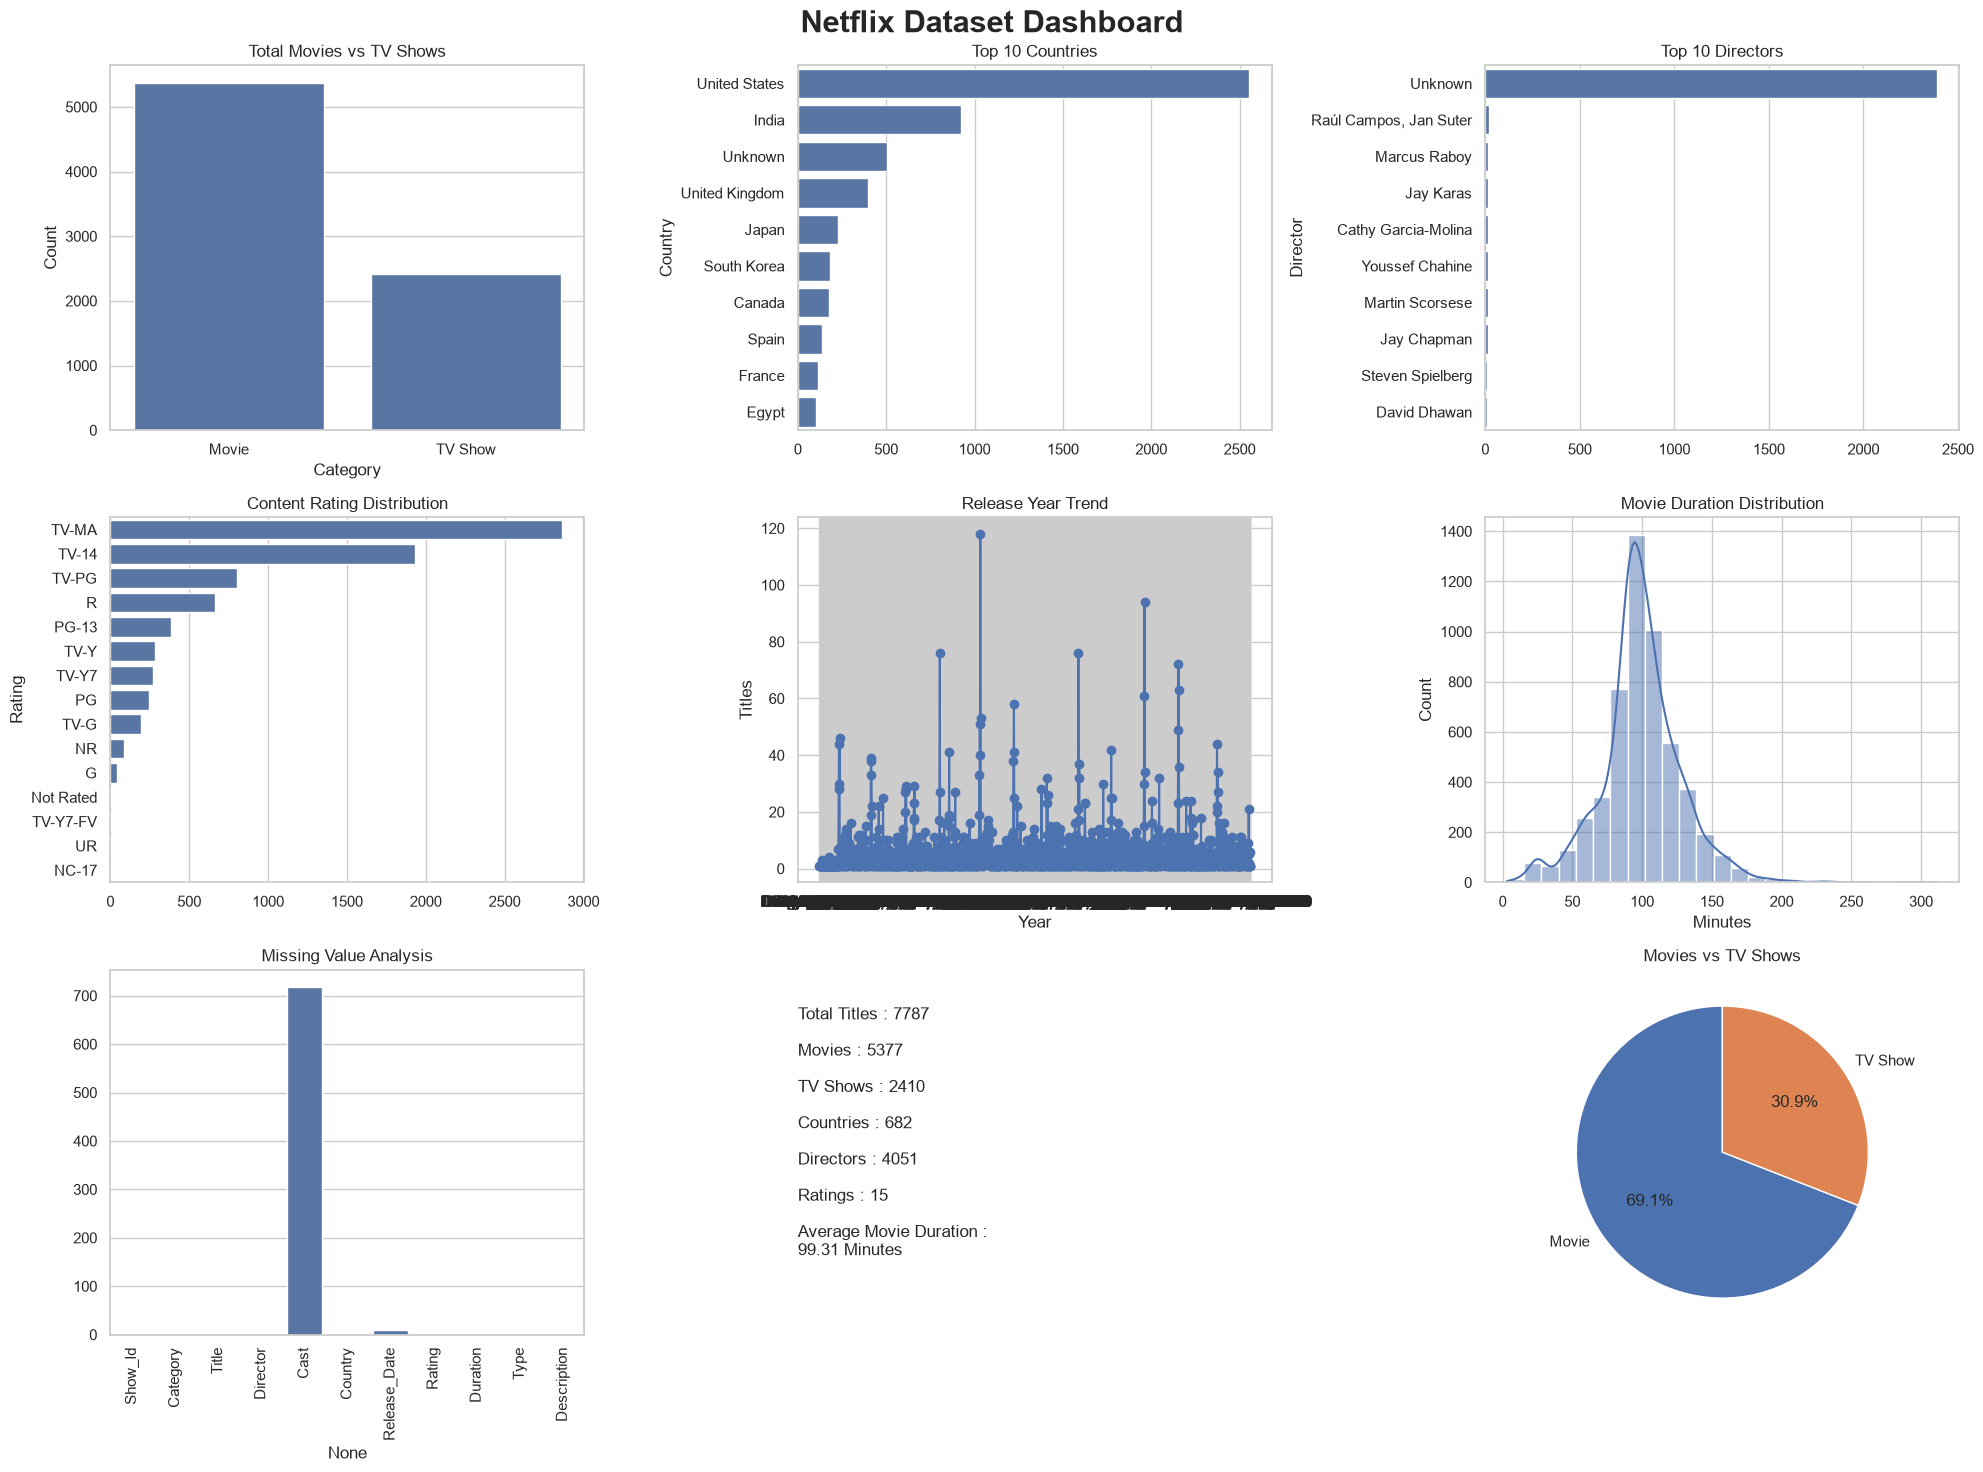

In [6]:
# Question 28
# Overall Netflix Dashboard
fig, ax = plt.subplots(3, 3, figsize=(20, 15))

# -------------------------------------------------------
# 1. Total Movies & TV Shows
# -------------------------------------------------------
category = df["Category"].value_counts()

sns.barplot(
    x=category.index,
    y=category.values,
    ax=ax[0,0]
)

ax[0,0].set_title("Total Movies vs TV Shows")
ax[0,0].set_xlabel("Category")
ax[0,0].set_ylabel("Count")

# -------------------------------------------------------
# 2. Top Countries
# -------------------------------------------------------
top_country = df["Country"].value_counts().head(10)

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    ax=ax[0,1]
)

ax[0,1].set_title("Top 10 Countries")

# -------------------------------------------------------
# 3. Top Directors
# -------------------------------------------------------
top_director = df["Director"].value_counts().head(10)

sns.barplot(
    x=top_director.values,
    y=top_director.index,
    ax=ax[0,2]
)

ax[0,2].set_title("Top 10 Directors")

# -------------------------------------------------------
# 4. Content Rating Distribution
# -------------------------------------------------------
rating = df["Rating"].value_counts()

sns.barplot(
    x=rating.values,
    y=rating.index,
    ax=ax[1,0]
)

ax[1,0].set_title("Content Rating Distribution")

# -------------------------------------------------------
# 5. Release Year Trend
# -------------------------------------------------------
release = df["Release_Date"].value_counts().sort_index()

ax[1,1].plot(
    release.index,
    release.values,
    marker="o"
)

ax[1,1].set_title("Release Year Trend")
ax[1,1].set_xlabel("Year")
ax[1,1].set_ylabel("Titles")

# -------------------------------------------------------
# 6. Movie Duration Distribution
# -------------------------------------------------------
sns.histplot(
    movies["Minutes"],
    bins=25,
    kde=True,
    ax=ax[1,2]
)

ax[1,2].set_title("Movie Duration Distribution")

# -------------------------------------------------------
# 7. Missing Value Analysis
# -------------------------------------------------------
missing = df.isnull().sum()

sns.barplot(
    x=missing.index,
    y=missing.values,
    ax=ax[2,0]
)

ax[2,0].tick_params(axis='x', rotation=90)
ax[2,0].set_title("Missing Value Analysis")

# -------------------------------------------------------
# 8. Dataset Summary
# -------------------------------------------------------
ax[2,1].axis("off")

summary = f"""
Total Titles : {len(df)}

Movies : {len(df[df['Category']=='Movie'])}

TV Shows : {len(df[df['Category']=='TV Show'])}

Countries : {df['Country'].nunique()}

Directors : {df['Director'].nunique()}

Ratings : {df['Rating'].nunique()}

Average Movie Duration :
{round(np.mean(movies['Minutes']),2)} Minutes

"""

ax[2,1].text(
    0,
    0.95,
    summary,
    fontsize=12,
    verticalalignment="top"
)

# -------------------------------------------------------
# 9. Movies vs TV Shows Pie Chart
# -------------------------------------------------------
ax[2,2].pie(
    category.values,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90
)

ax[2,2].set_title("Movies vs TV Shows")

plt.suptitle(
    "Netflix Dataset Dashboard",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [8]:
# Question 1: Find the total number of Movies and TV Shows.
total_movies = df[df["Category"] == "Movie"].shape[0]
total_tvshows = df[df["Category"] == "TV Show"].shape[0]

print("Total Movies :", total_movies)
print("Total TV Shows :", total_tvshows)

Total Movies : 5377
Total TV Shows : 2410


In [9]:
# Question 2: Identify the percentage of Movies vs TV Shows.
category_percent = (df["Category"].value_counts(normalize=True) * 100).round(2)

print(category_percent)

Category
Movie      69.05
TV Show    30.95
Name: proportion, dtype: float64


In [10]:
# Question 3: Find the Top 10 countries producing Netflix content.
top_10_countries = df["Country"].value_counts().head(10)

print(top_10_countries)

Country
United States     2555
India              923
Unknown            507
United Kingdom     397
Japan              226
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Name: count, dtype: int64


In [11]:
# Question 4: Determine which director has directed the highest number of titles.
top_director = df["Director"].value_counts().head(1)

print(top_director)

Director
Unknown    2388
Name: count, dtype: int64


In [12]:
# Question 5: Find the most common content rating.
most_common_rating = df["Rating"].mode()[0]

print("Most Common Rating :", most_common_rating)

Most Common Rating : TV-MA


In [15]:
# Question 6: Analyze content released over the years

df["Year"] = pd.to_datetime(
    df["Release_Date"].str.strip(),
    format="mixed",
    errors="coerce"
).dt.year

release_per_year = df["Year"].value_counts().sort_index()

print(release_per_year)

Year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      25
2015.0      88
2016.0     443
2017.0    1225
2018.0    1685
2019.0    2153
2020.0    2009
2021.0     117
Name: count, dtype: int64


In [16]:
# Question 7: Identify the year with the highest number of releases

year = pd.to_datetime(
    df["Release_Date"].astype(str).str.strip(),
    errors="coerce"
).dt.year

peak_year = year.value_counts().idxmax()
peak_count = year.value_counts().max()

print("Peak Release Year :", int(peak_year))
print("Number of Releases :", peak_count)

Peak Release Year : 2019
Number of Releases : 2153


In [17]:
# Question 8: Find the longest movie available on Netflix.
longest_movie = movies.loc[movies["Minutes"].idxmax()]

print("Title :", longest_movie["Title"])
print("Duration :", longest_movie["Duration"])

Title : Black Mirror: Bandersnatch
Duration : 312 min


In [18]:
# Question 9: Calculate the average movie duration.
average_duration = movies["Minutes"].mean()

print("Average Movie Duration :", round(average_duration, 2), "Minutes")

Average Movie Duration : 99.31 Minutes


In [19]:
# Question 10: Find the most frequently appearing actor.
top_actor = (
    df["Cast"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(1)
)

print(top_actor)

Cast
Anupam Kher    42
Name: count, dtype: int64


In [20]:
# Question 11: Analyze the distribution of content ratings by category.
rating_category = pd.crosstab(df["Category"], df["Rating"])

print(rating_category)

Rating     G  NC-17  NR  Not Rated   PG  PG-13    R  TV-14  TV-G  TV-MA  \
Category                                                                  
Movie     39      3  79          5  247    386  663   1272   111   1845   
TV Show    0      0   5          2    0      0    2    659    83   1018   

Rating    TV-PG  TV-Y  TV-Y7  TV-Y7-FV  UR  
Category                                    
Movie       505   117     95         5   5  
TV Show     301   163    176         1   0  


In [21]:
# Question 12: Find the countries producing both Movies and TV Shows.
country_category = pd.crosstab(df["Country"], df["Category"])

both = country_category[
    (country_category["Movie"] > 0) &
    (country_category["TV Show"] > 0)
]

print(both)

Category                                  Movie  TV Show
Country                                                 
Argentina                                    34       16
Argentina, Spain                              7        1
Australia                                    37       46
Australia, Canada                             1        1
Australia, United States                      7        3
...                                         ...      ...
United States, Russia                         2        1
United States, Sweden                         2        1
United States, United Kingdom                30        7
United States, United Kingdom, Australia      3        1
Unknown                                     230      277

[93 rows x 2 columns]


In [22]:
# Question 13: Determine which month has the highest number of releases.
df["Month"] = pd.to_datetime(
    df["Release_Date"].astype(str).str.strip(),
    errors="coerce"
).dt.month_name()

month_release = df["Month"].value_counts()

print(month_release)

print("\nHighest Release Month :", month_release.idxmax())
print("Number of Releases :", month_release.max())

Month
December     833
October      785
January      757
November     738
March        669
September    619
August       618
April        601
July         600
May          543
June         542
February     472
Name: count, dtype: int64

Highest Release Month : December
Number of Releases : 833


In [23]:
# Question 14: Calculate the percentage of missing values in each column.
missing_percentage = ((df.isnull().sum() / len(df)) * 100).round(2)

print(missing_percentage)

Show_Id         0.00
Category        0.00
Title           0.00
Director        0.00
Cast            9.22
Country         0.00
Release_Date    0.13
Rating          0.00
Duration        0.00
Type            0.00
Description     0.00
Year            0.13
Month           0.13
dtype: float64


In [24]:
# Question 15: Find the distribution of content Type.
type_distribution = df["Type"].value_counts()

print(type_distribution)

Type
Documentaries                                                                      334
Stand-Up Comedy                                                                    321
Dramas, International Movies                                                       320
Comedies, Dramas, International Movies                                             243
Dramas, Independent Movies, International Movies                                   215
                                                                                  ... 
Anime Features, International Movies, Sci-Fi & Fantasy                               1
LGBTQ Movies, Thrillers                                                              1
Action & Adventure, Sports Movies                                                    1
Kids' TV, Reality TV, Science & Nature TV                                            1
International TV Shows, Spanish-Language TV Shows, Stand-Up Comedy & Talk Shows      1
Name: count, Length: 492, dtype: int64

In [25]:
# Question 16: Find the Top 15 directors with the highest number of titles.
top_15_directors = df["Director"].value_counts().head(15)

print(top_15_directors)

Director
Unknown                   2388
Raúl Campos, Jan Suter      18
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Steven Spielberg            10
David Dhawan                 9
Kunle Afolayan               8
Hakan Algül                  8
Ryan Polito                  8
Shannon Hartman              8
Johnnie To                   8
Name: count, dtype: int64


In [26]:
# Question 17: Find the most common content rating in each country.
country_rating = (
    df.groupby("Country")["Rating"]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

print(country_rating)

Country
Argentina                                              TV-MA
Argentina, Brazil, France, Poland, Germany, Denmark    TV-14
Argentina, Chile                                       TV-14
Argentina, Chile, Peru                                 TV-MA
Argentina, France                                      TV-MA
                                                       ...  
Venezuela                                              TV-14
Venezuela, Colombia                                       NR
Vietnam                                                TV-14
West Germany                                           TV-MA
Zimbabwe                                                TV-G
Name: Rating, Length: 682, dtype: str


In [27]:
# Question 18: Compare Movies vs TV Shows released over the years.
year_data = pd.to_datetime(
    df["Release_Date"].astype(str).str.strip(),
    errors="coerce"
).dt.year

comparison = pd.crosstab(year_data, df["Category"])

print(comparison)

Category      Movie  TV Show
Release_Date                
2008.0            1        1
2009.0            2        0
2010.0            1        0
2011.0           13        0
2012.0            3        0
2013.0            6        5
2014.0           19        6
2015.0           58       30
2016.0          258      185
2017.0          864      361
2018.0         1255      430
2019.0         1497      656
2020.0         1312      697
2021.0           88       29


In [28]:
# Question 19: Find the shortest movie available on Netflix.
shortest_movie = movies.loc[movies["Minutes"].idxmin()]

print("Title :", shortest_movie["Title"])
print("Duration :", shortest_movie["Duration"])

Title : Silent
Duration : 3 min


In [29]:
# Question 20: Find the countries with the highest diversity of ratings.
rating_diversity = df.groupby("Country")["Rating"].nunique().sort_values(ascending=False)

print(rating_diversity.head(10))

Country
United States            15
Canada                   13
India                    12
Australia                11
Unknown                  11
Canada, United States    10
United Kingdom           10
United States, Canada    10
France                   10
Japan                     9
Name: Rating, dtype: int64


In [30]:
# Question 21: Analyze title length (number of characters).
df["Title_Length"] = df["Title"].str.len()

print("Average Title Length :", round(df["Title_Length"].mean(),2))

Average Title Length : 17.63


In [31]:
# Question 22: Find the most common words used in Netflix titles.
from collections import Counter

words = " ".join(df["Title"].dropna()).lower().split()

common_words = Counter(words).most_common(10)

print(common_words)

[('the', 1928), ('of', 609), ('a', 306), ('in', 240), ('and', 199), ('to', 171), ('&', 153), ('love', 134), ('my', 127), ('2', 92)]


In [32]:
# Question 23: Analyze description length for Movies vs TV Shows.
df["Description_Length"] = df["Description"].str.len()

description_analysis = df.groupby("Category")["Description_Length"].mean()

print(description_analysis)

Category
Movie      143.452297
TV Show    142.315353
Name: Description_Length, dtype: float64


In [33]:
# Question 24: Find duplicate titles in the dataset.
duplicate_titles = df[df.duplicated("Title", keep=False)]

print(duplicate_titles[["Title","Category"]])
print("Duplicate Title Count :", duplicate_titles["Title"].nunique())

Empty DataFrame
Columns: [Title, Category]
Index: []
Duplicate Title Count : 0


In [34]:
# Question 25: Identify directors who directed both Movies and TV Shows.
director_category = pd.crosstab(df["Director"], df["Category"])

both_directors = director_category[
    (director_category["Movie"]>0) &
    (director_category["TV Show"]>0)
]

print(both_directors)

Category                           Movie  TV Show
Director                                         
Alessandro Angulo                      1        1
Anurag Basu                            4        1
BB Sasore                              1        1
Cosima Spender                         2        1
Dan Forrer                             1        1
Daniel Kontur                          1        1
David Ayer                             2        1
Eli Roth                               2        1
Estela Renner                          1        1
Jalil Lespert                          2        1
Jay Chandrasekhar                      1        1
Jerry Seinfeld                         1        1
Justin Webster                         1        1
Kobun Shizuno, Hiroyuki Seshita        2        1
Kyran Kelly                            1        1
Manolo Caro                            1        1
Marcus Raboy                          15        1
Mark Tonderai                          1        1


In [35]:
# Question 26: Find the trend of family-friendly content.
family = df[df["Rating"].isin(["G","PG","TV-G","TV-Y","TV-Y7"])]

family["Year"] = pd.to_datetime(
    family["Release_Date"].astype(str).str.strip(),
    errors="coerce"
).dt.year

print(family["Year"].value_counts().sort_index())

Year
2012.0      1
2013.0      2
2014.0      7
2015.0     24
2016.0     71
2017.0    130
2018.0    171
2019.0    249
2020.0    350
2021.0     24
Name: count, dtype: int64


In [36]:
# Question 27: Countries contributing to mature-rated content.
mature = df[df["Rating"].isin(["TV-MA","R","NC-17"])]

print(mature["Country"].value_counts().head(10))

Country
United States     1245
India              230
United Kingdom     199
Unknown            161
Spain              111
South Korea         83
Japan               82
France              77
Canada              77
Mexico              73
Name: count, dtype: int64


In [39]:
# Question 28
# Overall Netflix Dashboard

# Dashboard already created using fig, ax = plt.subplots(3,3, figsize=(20,15))

# It includes:
# 1. Total Movies vs TV Shows
# 2. Top 10 Countries
# 3. Top 10 Directors
# 4. Content Rating Distribution
# 5. Release Year Trend
# 6. Movie Duration Distribution
# 7. Missing Value Analysis
# 8. Dataset Summary (KPIs)
# 9. Movies vs TV Shows Pie Chart

print("Overall Netflix Dashboard Created Successfully")

Overall Netflix Dashboard Created Successfully


In [37]:
# Question 29: Perform Exploratory Data Analysis (EDA).
print(df.describe(include="all"))

print("\nMissing Values")
print(df.isnull().sum())

print("\nDataset Shape :", df.shape)

       Show_Id Category Title Director                Cast        Country  \
count     7787     7787  7787     7787                7069           7787   
unique    7787        2  7787     4051                6831            682   
top         s1    Movie    3%  Unknown  David Attenborough  United States   
freq         1     5377     1     2388                  18           2555   
mean       NaN      NaN   NaN      NaN                 NaN            NaN   
std        NaN      NaN   NaN      NaN                 NaN            NaN   
min        NaN      NaN   NaN      NaN                 NaN            NaN   
25%        NaN      NaN   NaN      NaN                 NaN            NaN   
50%        NaN      NaN   NaN      NaN                 NaN            NaN   
75%        NaN      NaN   NaN      NaN                 NaN            NaN   
max        NaN      NaN   NaN      NaN                 NaN            NaN   

           Release_Date Rating  Duration           Type  \
count           

In [38]:
# Question 30: Generate business insights.
print("Business Insights")
print("---------------------------")
print("1. Increase investment in countries producing the most content.")
print("2. Focus more on TV-MA and TV-14 content because they dominate Netflix.")
print("3. Produce more content in peak release years.")
print("4. Collaborate with top directors for higher audience reach.")
print("5. Expand family-friendly content to attract more viewers.")

Business Insights
---------------------------
1. Increase investment in countries producing the most content.
2. Focus more on TV-MA and TV-14 content because they dominate Netflix.
3. Produce more content in peak release years.
4. Collaborate with top directors for higher audience reach.
5. Expand family-friendly content to attract more viewers.
